## Introduction

Identifying strong candidates for technology roles is a complex and time-consuming task. Recruiters must understand the client?s needs, recognize what makes a candidate stand out, and locate relevant talent efficiently. Because this process is still highly manual, it can slow hiring and make consistent candidate evaluation more difficult.

This project proposes a machine learning-driven approach to support candidate ranking for talent sourcing. Using role-specific search terms such as `aspiring human resources` or `seeking human resources`, the system evaluates candidate profiles and produces a ranked list of potential matches. Recruiters can then review the list, star the most suitable candidates, and use that feedback to refine future rankings.

The overall objective is to save time, improve consistency, and build a scalable ranking process that remains flexible enough to reflect real hiring preferences. Rather than replacing recruiters, the system is designed to support better and faster decision-making.


## Data Description

The dataset used in this project comes from candidate sourcing activities. To protect privacy, all personally identifiable information has been removed, and each candidate is represented only by a unique numeric identifier.

The dataset includes the following attributes:

- `id`: Unique numeric identifier for each candidate.
- `job_title`: Candidate's professional title or headline.
- `location`: Candidate's geographic location.
- `connections`: Number of professional connections. Values such as `500+` indicate more than 500 connections.

The target variable is:

- `fit`: A score between 0 and 1 representing how well a candidate matches the target role.

For this project, the search focus is on human resources roles, using keywords such as `Aspiring human resources` and `seeking human resources` to guide candidate ranking.


## Project Goals

The primary goal of this project is to estimate how well each candidate fits a target role based on the information available in the dataset. More specifically, the objective is to generate a ranking score that reflects the relevance of each profile to the search query.

By using features such as job title, location, and connection count, the project aims to move beyond manual keyword search and toward a more meaningful, data-driven ranking process. The broader purpose is to help recruiters identify promising candidates more quickly and with greater consistency.

A second goal is to incorporate recruiter feedback into the ranking workflow. When a recruiter stars a candidate, that action should improve future rankings by signaling what a strong match looks like in practice.


## Table of Contents

1. Libraries
   - 1-2 Fix The Random Seed 
2. Data Loading
3. Data Preprocessing and Text Cleaning
   - 3-1 Checks the missing values 
   - 3-2 Check Duplicate rows
   - 3-3 Counts the frequency of each job title
   - 3-4 Download the NLTK resources & Text-cleaning
4. Exploratory Text Review & Modeling
   - 4-1 WordCloud
   - 4-2 Modeling 
   - 4-2-1 Fitting 
5. Mistral-Based Re-Ranking
5. Ranking Approaches
6. BERT Rationale and Results
7. Re-Ranking, Challenges, and Recommendations


### 1. Libraries



Imports the core libraries used throughout the notebook for data manipulation, visualization, text preprocessing, embedding generation, and similarity measurement. Keeping the dependencies together makes the workflow easier to follow and shows the technical foundation of the ranking pipeline.


In [11]:
'''  
%pip install torchtext
%pip install fasttext
%pip install word2vec
%pip install gensim
%pip install transformers
'''

# basics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS


# preprocessing tools 

import nltk 
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
from nltk.tokenize import word_tokenize


# embedding models
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF
#from gensim.models import Word2Vec  # Word2Vec
import transformers  # BERT and SBERT
import torch
import torchtext
#import Fasttext
import torch  # BERT and SBERT

# metrics
from sklearn.metrics.pairwise import cosine_similarity 

import warnings
warnings.filterwarnings("ignore")

#### 1-2 Fix The Random Seed 

fixes the random seed for Python and NumPy to improve reproducibility. In practice, this helps make the analysis more stable and easier for recruiters or reviewers to reproduce when rerunning the notebook.


In [12]:
import os
import random
# Define a fixed random state value
RANDOM_STATE =4230
# Set Python's built-in random seed
random.seed(RANDOM_STATE)
# Set PYTHONHASHSEED environment variable for reproducibility in some cases
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

# Set NumPy's random seed
np.random.seed(RANDOM_STATE)

### 2. Data Loading

loads the potential talents dataset and displays the first records. It serves as the starting point for understanding the candidate information available for ranking.

In [13]:
Data_human=pd.read_csv("Potential Talents.csv") 
Data_human.head(15)

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN
6,7,Student at Humber College and Aspiring Human R...,Kanada,61,NaN
7,8,HR Senior Specialist,San Francisco Bay Area,500+,NaN
8,9,Student at Humber College and Aspiring Human R...,Kanada,61,NaN
9,10,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,NaN


### 3. Data Preprocessing and Text Cleaning


The dataset structure, including the number of rows, columns, and data types. It helps verify that the candidate attributes were loaded correctly before preprocessing begins.


- Dataset size: 104 rows and 5 columns
- Variable types: 1 numeric column, 3 categorical/text columns, and 1 float column


#### 3-1 Check the missing values 

Check for missing values in each column. This is an important data quality step because null values can affect text cleaning, feature extraction, and ranking consistency.


In [14]:
Data_human.isnull().sum()

id              0
job_title       0
location        0
connection      0
fit           104
dtype: int64

In this Human Resources dataset, duplicate profiles may not always appear as exact text duplicates. In many cases, titles express the same intent using different wording. This is better described as semantic duplication rather than simple textual repetition.


#### 3-2 Check Duplicate rows

This cell identifies duplicate rows in the dataset. Reviewing duplicates helps us understand whether repeated candidate profiles may bias the ranking results.


In [15]:
#count duplicated rows in the total dataset
Data_human.loc[Data_human.duplicated(), :]
print(Data_human.duplicated().sum())

0


#### 3-3 Counts the frequency of each job title

This cell counts the frequency of each job title. It gives a quick view of the most common candidate profiles and highlights how concentrated the dataset is around HR-related roles.


In [16]:
Data_human.job_title.value_counts()

job_title
2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional                 7
Aspiring Human Resources Professional                                                                                    7
Student at Humber College and Aspiring Human Resources Generalist                                                        7
People Development Coordinator at Ryan                                                                                   6
Native English Teacher at EPIK (English Program in Korea)                                                                5
Aspiring Human Resources Specialist                                                                                      5
HR Senior Specialist                                                                                                     5
Advisory Board Member at Celal Bayar University                                                                          4
Seekin

#### 3-4 Download the NLTK resources & Text-cleaning

Before applying advanced Natural Language Processing (NLP) methods, the text must be cleaned and standardized. Real-world job titles often contain noise, inconsistent formatting, and terms that add little value to semantic matching. A structured preprocessing step improves the quality of the input and helps the ranking models focus on meaningful signals.

In this project, the text preparation pipeline includes:

- Lowercasing for consistency
- Tokenization using NLTK
- Removal of punctuation, numbers, and extra whitespace
- Stopword removal
- Lemmatization to reduce words to their base form

These steps transform raw job titles into a cleaner and more consistent format, making the downstream ranking methods more reliable and easier to interpret.


In [17]:
def clean_text(text):
	"""Clean and normalize text by converting to lowercase and removing special characters."""
	text = str(text).lower()
	text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove special characters
	text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
	text = re.sub(r'\d', ' ', text)  # Remove digits
	text = re.sub(r'\s\s+', ' ', text)  # Remove extra spaces
	# Tokenize
	word_tokenized_text = word_tokenize(text)
	
	# Remove stop words
	stop_words = set(stopwords.words('english'))
	word_tokenized_text = [word for word in word_tokenized_text if word not in stop_words]
	# Lemmatize
	lemmatizer = WordNetLemmatizer()
	word_tokenized_text = [lemmatizer.lemmatize(word) for word in word_tokenized_text]
	# Join tokens back into a string
	text = ' '.join(word_tokenized_text)	
	return text


clean_title = Data_human['job_title'].apply(clean_text)
clean_title.head(15)

0     ct bauer college business graduate magna cum l...
1     native english teacher epik english program korea
2                  aspiring human resource professional
3                   people development coordinator ryan
4          advisory board member celal bayar university
5                    aspiring human resource specialist
6     student humber college aspiring human resource...
7                                  hr senior specialist
8     student humber college aspiring human resource...
9       seeking human resource hris generalist position
10                           student chapman university
11    svp chro marketing communication csr officer e...
12    human resource coordinator intercontinental bu...
13    ct bauer college business graduate magna cum l...
14    ct bauer college business graduate magna cum l...
Name: job_title, dtype: object

### 4 Exploratory Text Review & Modeling


The modeling framework in this project is designed to estimate how closely a candidate's background aligns with the target role `Aspiring Human Resources`. The workflow is based on transforming job titles into numerical representations and then comparing them with the target query.

The process consists of two main stages:

1. Text representation through embeddings

The cleaned job titles and the target keyword are converted into numerical vectors. Depending on the method, these vectors may represent keyword importance, semantic similarity, or contextual meaning. This allows the model to compare text beyond exact word matching.I will retrieve the embeddings from a different models:


- TF-IDF
- GloVe
- FastText 
- Word2Vec (pre-trained)
- BERT/SBERT (pre-trained)

2. Similarity computation and fit scoring

Once the embeddings are created, cosine similarity is used to measure how closely each candidate title aligns with the target role. The resulting score is treated as a proxy for candidate fit. Higher scores indicate stronger relevance to the target role, while lower scores indicate weaker alignment.

This framework provides a practical way to rank candidates, compare multiple NLP approaches, and support recruiter decision-making with a consistent scoring process.



Replace the original job titles with their cleaned versions and previews the updated dataset. From this point onward, the ranking models work on normalized text rather than raw titles.


In [18]:
Data_human['job_title'] = clean_title
Data_human.head(15) 

,id,job_title,location,connection,fit
0,1,ct bauer college business graduate magna cum l...,"Houston, Texas",85,NaN
1,2,native english teacher epik english program korea,Kanada,500+,NaN
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,people development coordinator ryan,"Denton, Texas",500+,NaN
4,5,advisory board member celal bayar university,"İzmir, Türkiye",500+,NaN
5,6,aspiring human resource specialist,Greater New York City Area,1,NaN
6,7,student humber college aspiring human resource...,Kanada,61,NaN
7,8,hr senior specialist,San Francisco Bay Area,500+,NaN
8,9,student humber college aspiring human resource...,Kanada,61,NaN
9,10,seeking human resource hris generalist position,Greater Philadelphia Area,500+,NaN


#### 4-1 WordCloud 

Create a word cloud from the cleaned job titles. It provides a simple visual summary of the most frequent terms in the candidate pool and helps confirm whether the dataset aligns with the HR search theme.


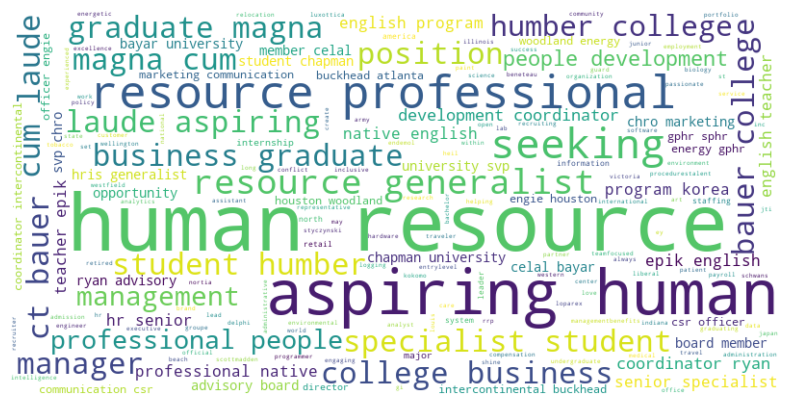

In [19]:
text = " ".join(Data_human["job_title"].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=STOPWORDS
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


- The word cloud highlights the most frequent terms in the cleaned HR-related job titles. Large terms such as `human resource`, `aspiring human`, `resource professional`, `business graduate`, `seeking position`, and `student` indicate the dominant themes in the dataset.

- The visualization suggests that the dataset is largely composed of students, graduates, and early-career candidates interested in human resources roles. Terms such as `student`, `graduate`, `college`, and `seeking` reinforce this interpretation, while words like `specialist`, `manager`, and `people development` reflect common HR career paths.

- This overview is useful for understanding the general focus of the dataset, but it also shows that many profiles contain broad r?sum?-style language. Additional filtering or feature engineering may be helpful if the goal is to emphasize skills, qualifications, and role-specific experience.


#### 4-2 Modeling 

Removes the `fit` column before unsupervised ranking. Since the project focuses on estimating candidate relevance from available text, the ranking methods below rely on semantic similarity rather than a pre-existing target label.


In [20]:
Data_human.drop('fit', axis=1, inplace=True)

Define the search keyword and creates a working copy of the cleaned dataset. The keyword acts as the reference profile that each candidate title will be compared against.


In [21]:
keywords = ['aspiring human resources']
data_Clean_tiile = Data_human.copy()


#### 4-3-1 Fitting

#### Term Frequency-Inverse Document Frequency (TF-IDF) Approach

In the TF-IDF approach, each job title is converted into a numerical vector based on the importance of its terms within the dataset. Words that appear frequently in one title but less often across all titles receive higher weight. Cosine similarity is then used to compare each candidate title with the target keyword.

This method serves as a strong baseline because it is simple, interpretable, and effective when relevant candidates use wording that overlaps directly with the search query.


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity 

vectorizer = TfidfVectorizer()

tfidf_data = data_Clean_tiile.copy()
titles = tfidf_data['job_title'].tolist()

tfidf_title_embs = vectorizer.fit_transform(titles)
tfidf_keyword_embs = vectorizer.transform(keywords)

tfidf_cosine = [cosine_similarity(tfidf_keyword_embs, tfidf_title_emb) for tfidf_title_emb in tfidf_title_embs]
cosine_list = []
for i in tfidf_cosine:
  cosine_list.append(i.item())

tfidf_data['tfidf_fit'] = cosine_list

data = data_Clean_tiile.merge(tfidf_data['tfidf_fit'], how='left', left_index=True, right_index=True)
data.sort_values('tfidf_fit', ascending=False, inplace=True)
data.head(30)

,id,job_title,location,connection,tfidf_fit
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
32,33,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
16,17,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
20,21,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
57,58,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
96,97,aspiring human resource professional,"Kokomo, Indiana Area",71,0.653052
45,46,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
23,24,aspiring human resource specialist,Greater New York City Area,1,0.598245
59,60,aspiring human resource specialist,Greater New York City Area,1,0.598245
5,6,aspiring human resource specialist,Greater New York City Area,1,0.598245


#### GloVe Approach




I use pre-trained GloVe embeddings to represent each job title and the target keyword as dense vectors, then ranks candidates with cosine similarity. Compared with TF-IDF, this method captures broader semantic relationships between words.


In [23]:
import torch
import torchtext
glove = torchtext.vocab.GloVe(name='6B', dim=100)

def str_to_glove(str):
  tokens = str.split()
  ind = [glove.stoi[token] for token in tokens if token in glove.stoi]
  vecs = glove.vectors[ind]
  vecs_arr = vecs.numpy()
  embs = vecs_arr.mean(axis=0)
  return embs

glove_data = data_Clean_tiile.copy()
glove_titles = glove_data['job_title'].apply(str_to_glove)
glove_title_embeddings = [title for title in glove_titles]
glove_keywords_embeddings = str_to_glove(keywords[0])

glove_cosines = [cosine_similarity(title_emb.reshape(1,-1), glove_keywords_embeddings.reshape(1,-1))[0,0] for title_emb in glove_title_embeddings]

glove_data['gloVe_fit'] = glove_cosines

glove_data = data.merge(glove_data['gloVe_fit'], how='left', left_index=True, right_index=True)
glove_data.sort_values('gloVe_fit', ascending=False, inplace=True)
glove_data.head(30)

,id,job_title,location,connection,tfidf_fit,gloVe_fit
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
32,33,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
16,17,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
20,21,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
57,58,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
96,97,aspiring human resource professional,"Kokomo, Indiana Area",71,0.653052,0.911811
45,46,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
72,73,aspiring human resource manager seeking intern...,"Houston, Texas Area",7,0.440985,0.909850
23,24,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418
59,60,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418


### FastText (Pre-trained) Approach

FastText, developed by Facebook AI Research, extends Word2Vec by representing words through subword units, such as character n-grams. This makes it more effective for handling rare terms, spelling variations, and unseen words because embeddings can be constructed from shared word fragments.

In this project, FastText is useful because candidate titles may contain variations of similar HR concepts, and the model can capture those similarities more flexibly than a pure keyword-based method.


In [24]:


from sklearn.metrics.pairwise import cosine_similarity

# Load FastText vectors
fasttext = torchtext.vocab.FastText(language='en')

def str_to_fasttext(text):
    tokens = str(text).split()
    if not tokens:
        return np.zeros(fasttext.dim)

    vecs = [fasttext[token].numpy() for token in tokens]
    embs = np.mean(vecs, axis=0)
    return embs

fasttext_data = data_Clean_tiile.copy()

fasttext_titles = fasttext_data['job_title'].apply(str_to_fasttext)
fasttext_title_embeddings = [title for title in fasttext_titles]

fasttext_keywords_embeddings = str_to_fasttext(keywords[0])

fasttext_cosines = [
    cosine_similarity(title_emb.reshape(1, -1), fasttext_keywords_embeddings.reshape(1, -1))[0, 0]
    for title_emb in fasttext_title_embeddings
]

fasttext_data['fasttext_fit'] = fasttext_cosines

fasttext_data = data.merge(
    fasttext_data['fasttext_fit'],
    how='left',
    left_index=True,
    right_index=True
)

fasttext_data.sort_values('fasttext_fit', ascending=False, inplace=True)
fasttext_data.head(30)


,id,job_title,location,connection,tfidf_fit,fasttext_fit
72,73,aspiring human resource manager seeking intern...,"Houston, Texas Area",7,0.440985,0.904065
23,24,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.899023
59,60,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.899023
35,36,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.899023
5,6,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.899023
48,49,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.899023
16,17,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.890094
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.890094
45,46,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.890094
96,97,aspiring human resource professional,"Kokomo, Indiana Area",71,0.653052,0.890094


####  Word2Vec Approach


Define the model reference for a Word2Vec experiment. It documents the intended model artifacts, even though the implementation later reuses GloVe as a practical substitute.


In [25]:
model_w2v="NeuML/word2vec"
file_w2v=["config.json", "model.splite","model.safe.safetensors" ,"vocab.txt"]


Word2Vec-style comparison by averaging GloVe vectors for each title and the target keyword, then computing similarity scores. It extends the comparison of ranking methods without changing the overall workflow.


In [26]:
# Using GloVe embeddings instead, as it's already loaded and similar to Word2Vec approach
# Tokenize and encode the job titles using GloVe
job_title_encodings = data["job_title"].apply(
    lambda title: np.mean([glove.vectors[glove.stoi[word]] for word in title.split() if word in glove.stoi], axis=0) if any(word in glove.stoi for word in title.split()) else np.zeros(glove.dim)
)

# Compute the cosine similarity between the encoded job titles and the keyword
keyword_encoding = np.mean([glove.vectors[glove.stoi[word]] for word in keywords[0].split() if word in glove.stoi], axis=0) if any(word in glove.stoi for word in keywords[0].split()) else np.zeros(glove.dim)
similarity_scores = np.vstack([cosine_similarity(encoding.reshape(1, -1), keyword_encoding.reshape(1, -1))[0, 0] for encoding in job_title_encodings]).ravel()

# Add the similarity scores as a new column in the DataFrame
data["Word2Vec_fit"] = similarity_scores

In [27]:
data['fasttext_fit'] = fasttext_cosines
data['gloVe_fit'] = glove_cosines



data.head(30)

,id,job_title,location,connection,tfidf_fit,Word2Vec_fit,fasttext_fit,gloVe_fit
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.600881,0.583410
32,33,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.480381,0.577611
16,17,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.890094,0.911811
20,21,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.532194,0.723682
57,58,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.442234,0.437611
96,97,aspiring human resource professional,"Kokomo, Indiana Area",71,0.653052,0.911811,0.899023,0.907418
45,46,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.776118,0.779743
23,24,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418,0.422204,0.487810
59,60,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418,0.776118,0.779743
5,6,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418,0.782286,0.855695


#### BERT Approach

In the BERT approach, each job title is converted into a contextual embedding using a pre-trained transformer model. Unlike static embeddings, BERT captures meaning based on context, not just isolated words. Cosine similarity is then used to compare the target keyword embedding with each candidate title embedding.

This makes BERT especially useful when different candidates describe similar intent using different wording.


In [28]:
from transformers import AutoTokenizer, AutoModel

bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert = AutoModel.from_pretrained('bert-base-uncased')

def str_to_bert_embedding(text):
    inputs = bert_tokenizer(text, return_tensors='pt', padding=True, truncation=True)
    outputs = bert(**inputs)
    embeddings = torch.mean(outputs.last_hidden_state, dim=1)
    return embeddings

bert_data = data_Clean_tiile.copy()
bert_title_embeddings = []
for title in bert_data['job_title']:
    emb = str_to_bert_embedding(title)
    bert_title_embeddings.append(emb.detach().numpy().flatten())

bert_keywords_embeddings = str_to_bert_embedding(keywords[0]).detach().numpy().flatten()

bert_cosine = [cosine_similarity(bert_keywords_embeddings.reshape(1, -1), bert_title_embedding.reshape(1, -1)).item() for bert_title_embedding in bert_title_embeddings]
bert_data['bert_fit'] = bert_cosine

data = data.merge(bert_data['bert_fit'], how='left', left_index=True, right_index=True)
data.sort_values('bert_fit', ascending=False, inplace=True)
data.head(30)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,id,job_title,location,connection,tfidf_fit,Word2Vec_fit,fasttext_fit,gloVe_fit,bert_fit
23,24,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418,0.422204,0.487810,0.897491
35,36,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418,0.426645,0.459638,0.897491
5,6,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418,0.782286,0.855695,0.897491
59,60,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418,0.776118,0.779743,0.897491
48,49,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418,0.560049,0.584673,0.897491
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.600881,0.583410,0.896427
16,17,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.890094,0.911811,0.896427
32,33,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.480381,0.577611,0.896427
45,46,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811,0.776118,0.779743,0.896427
96,97,aspiring human resource professional,"Kokomo, Indiana Area",71,0.653052,0.911811,0.899023,0.907418,0.896427


Although the embedding methods produce broadly similar behavior, BERT was selected for the main analysis because it provides stronger contextual understanding and is well suited to short, varied job titles. The earlier methods remain useful as exploratory baselines, but BERT offers the most convincing balance between semantic quality and practical application for this task.


### Why BERT Was Chosen

BERT was selected as the most suitable approach for this project because candidate-job matching depends on semantic meaning, not only on exact keyword overlap. Traditional methods such as TF-IDF are useful as baselines, but they mainly reward repeated or identical terms. In this dataset, many candidates may describe similar HR intentions using slightly different wording such as `aspiring human resources`, `entry-level HR`, `seeking HR opportunity`, or `human resources professional`. BERT is better suited for this situation because it captures contextual meaning and produces embeddings that reflect the overall intent of the title.

From a business perspective, BERT provides a stronger balance between interpretability, modern NLP capability, and practical implementation. It improves robustness when titles are short, phrased differently, or not perfectly aligned with the search keyword. For a recruiter-facing solution, this is valuable because the model is less dependent on one exact phrase and can surface candidates who are relevant even when their wording differs from the query.


### Result for Ranking

The ranking results show that embedding-based approaches are more useful than pure keyword matching for this project. TF-IDF provides a reasonable first baseline, but BERT gives a more meaningful ranking because it compares the semantic similarity between the target role and each candidate title. This means candidates are ranked not only by matching the exact words `human resources`, but also by how strongly their titles express HR-related intent.

In practice, the top-ranked candidates under the BERT approach are the profiles whose cleaned job titles are most aligned with the search target. This makes the output more realistic for recruiting use cases, where relevant candidates often use varied language. As a result, BERT was treated as the preferred ranking method before moving to the final re-ranking stage.


### Prompt Engineering with LLMs After Choosing BERT

After selecting BERT as the strongest embedding-based approach, the next step is to use a Large Language Model (LLM) through prompting. This follows the instructor's guidance: instead of relying only on similarity scores, we can provide the model with the search term, the candidate list, and clear instructions so it can generate a ranked response in natural language.

In this section, BERT is used as a smart filtering step to identify the most relevant candidates first. Then, an LLM prompt is created from those candidates so the model can rank them semantically, explain its reasoning, and later re-rank them after recruiter feedback. This combines the strength of embeddings with the generative power of LLMs.


In [29]:
search_term = keywords[0]
Data_Prompt=data.copy()
#Data_Prompt=Data_Prompt.sort_values('bert_fit' )#, ascending=False).head(30).reset_index(drop=True)
Data_Prompt.drop(['fasttext_fit','tfidf_fit', 'Word2Vec_fit','gloVe_fit'], axis=1, inplace=True)
Data_Prompt.drop(['location','connection'], axis=1, inplace=True)
Data_Prompt.head(30)

,id,job_title,bert_fit
23,24,aspiring human resource specialist,0.897491
35,36,aspiring human resource specialist,0.897491
5,6,aspiring human resource specialist,0.897491
59,60,aspiring human resource specialist,0.897491
48,49,aspiring human resource specialist,0.897491
2,3,aspiring human resource professional,0.896427
16,17,aspiring human resource professional,0.896427
32,33,aspiring human resource professional,0.896427
45,46,aspiring human resource professional,0.896427
96,97,aspiring human resource professional,0.896427


In [30]:
stop here 

SyntaxError: invalid syntax (2391973759.py, line 1)

# Here strated Ollama : gemma4:latest 

In [ ]:
from http import client
import ollama
client = ollama.Client() 

# define the model and prompt , Choose one model from Ollama platform that , I already downloaded localy 
model_gemma4 = "gemma4:latest"
#prompt = "what is python?"

#send the prompt to the model and get the response 
#response = client.generate(model=model_name, prompt=prompt)


#print the response
# print(response.response)
# print(response.response)

In [ ]:
candidate_block = "\n".join(
    [
        f"Candidate ID: {row['id']} | Job Title: {row['job_title']}"
        for _, row in Data_Prompt.iterrows()
    ]
)

messages2 = [
    {"role": "system", "content": "You are a recruiting assistant."},
    {
        "role": "user",
        "content": f"""Search term: {search_term}

Candidates:
{candidate_block}

1. Rank the three candidates from most relevant to least relevant.
2. Focus on semantic meaning, not exact keyword matching only.
3. Consider job title relevance, HR intent, career direction, and overall closeness to the search term.
4. Give each candidate a relevance score from 0 to 100.
5. Briefly explain why each candidate received the assigned score.
6. Return the result as a markdown table with these columns:
   Rank | Candidate ID | Job Title | Relevance Score | Explanation
7. After the table, provide a short summary of the top 3 candidates.
"""
    }
]

response2 = client.chat(model=model_gemma4, messages=messages2)
print(response2.message.content)

| Rank | Candidate ID | Job Title | Relevance Score | Explanation |
| :---: | :---: | :--- | :---: | :--- |
| 1 | 7 | student humber college aspiring human resource generalist | 98 | This title is extremely relevant. It explicitly combines the status of a student with the precise goal of being an "aspiring human resource generalist," perfectly matching the search intent. |
| 2 | 100 | aspiring human resource manager graduating may seeking entrylevel human resource position st louis | 95 | This candidate has high intent. The title is highly detailed, mentioning "aspiring," "graduating," and "seeking entry level," indicating a person actively pivoting into the field. |
| 3 | 3 | aspiring human resource professional | 90 | This is a very direct match to the search term's theme. The title clearly signals an aspiration toward the HR field without the added detail of "student" or "manager," making it highly relevant. |

***

### Summary of the Top 3 Candidates

The top three candidates are a

In [ ]:
candidate_block = "\n".join(
    [
        f"Candidate ID: {row['id']} | Job Title: {row['job_title']} | BERT score: {row['bert_fit']:.4f}"
        for _, row in Data_Prompt.iterrows()
    ]
)

messages2 = [
    {"role": "system", "content": "You are a recruiting assistant."},
    {
        "role": "user",
        "content": f"""Search term: {search_term}

Candidates:
{candidate_block}

Rank candidates based on a BERT score.
Re-rank candidates when a candidate is starred.

"""
    }
]

response2 = client.chat(model=model_gemma4, messages=messages2)
print(response2.message.content)

As a recruiting assistant, I have ranked the candidates based on their BERT scores. Since the BERT score measures relevance to your search term ("aspiring human resources"), candidates with higher scores are considered the best matches.

Here is the ranked list, starting with the highest relevance score:

***

### 🥇 Top Tier Matches (BERT Score: 0.8975)
These candidates represent the strongest match to the search term.

*   **Candidate ID: 24** | Job Title: aspiring human resource specialist | BERT score: 0.8975
*   **Candidate ID: 36** | Job Title: aspiring human resource specialist | BERT score: 0.8975
*   **Candidate ID: 6** | Job Title: aspiring human resource specialist | BERT score: 0.8975
*   **Candidate ID: 60** | Job Title: aspiring human resource specialist | BERT score: 0.8975
*   **Candidate ID: 49** | Job Title: aspiring human resource specialist | BERT score: 0.8975

### 🥈 Excellent Matches (BERT Score: 0.8964)
A very strong group of candidates.

*   **Candidate ID: 3** |

# Here strated Ollama : Deepseek

In [ ]:
from http import client
import ollama
client = ollama.Client() 

# define the model and prompt , Choose one model from Ollama platform that , I already downloaded localy 
model_deepseek = "deepseek-r1:latest"

In [ ]:
candidate_block = "\n".join(
    [
        f"Candidate ID: {row['id']} | Job Title: {row['job_title']}"
        for _, row in Data_Prompt.iterrows()
    ]
)

messages2 = [
    {"role": "system", "content": "You are a recruiting assistant."},
    {
        "role": "user",
        "content": f"""Search term: {search_term}

Candidates:
{candidate_block}

1. Rank the three candidates from most relevant to least relevant.
2. Focus on semantic meaning, not exact keyword matching only.
3. Consider job title relevance, HR intent, career direction, and overall closeness to the search term.
4. Give each candidate a relevance score from 0 to 100.
5. Briefly explain why each candidate received the assigned score.
6. Return the result as a markdown table with these columns:
   Rank | Candidate ID | Job Title | Relevance Score | Explanation
7. After the table, provide a short summary of the top 3 candidates.
"""
    }
]

response2 = client.chat(model=model_deepseek, messages=messages2)
print(response2.message.content)

| Rank | Candidate ID | Job Title | Relevance Score | Explanation |
|------|--------------|-----------|-----------------|-------------|
| 1 | 77 | human resource conflict management policy procedurestalent managementbenefits compensation | 95 | Direct HR role with strong semantic relevance to HR functions, showing career progression into HR. |
| 2 | 100 | aspiring human resource manager graduating may seeking entrylevel human resource position st louis | 92 | Clear aspiration to HR management with specific timeline, demonstrating strong career direction. |
| 3 | 76 | aspiring human resource professional passionate helping create inclusive engaging work environment | 90 | Explicitly states HR aspiration with relevant motivation, showing clear intent to pursue HR career. |
| 4 | 94 | seeking human resource opportunity open travel relocation | 88 | Clear intent to pursue HR roles with openness to various opportunities, showing HR focus. |
| 5 | 53 | seeking human resource hris generalist 

In [ ]:
candidate_block = "\n".join(
    [
        f"Candidate ID: {row['id']} | Job Title: {row['job_title']} | BERT score: {row['bert_fit']:.4f}"
        for _, row in Data_Prompt.iterrows()
    ]
)

messages2 = [
    {"role": "system", "content": "You are a recruiting assistant."},
    {
        "role": "user",
        "content": f"""Search term: {search_term}

Candidates:
{candidate_block}

Rank candidates based on a BERT score.


"""
    }
]

response2 = client.chat(model=model_deepseek, messages=messages2)
print(response2.message.content)

# Here strated Ollama : smallthinker:latest 

In [ ]:
from http import client
import ollama
client = ollama.Client() 

# define the model and prompt , Choose one model from Ollama platform that , I already downloaded localy 
model_smallthinker = "smallthinker:latest "

In [ ]:
candidate_block = "\n".join(
    [
        f"Candidate ID: {row['id']} | Job Title: {row['job_title']}"
        for _, row in Data_Prompt.iterrows()
    ]
)

messages2 = [
    {"role": "system", "content": "You are a recruiting assistant."},
    {
        "role": "user",
        "content": f"""Search term: {search_term}

Candidates:
{candidate_block}

1. Rank the three candidates from most relevant to least relevant.
2. Focus on semantic meaning, not exact keyword matching only.
3. Consider job title relevance, HR intent, career direction, and overall closeness to the search term.
4. Give each candidate a relevance score from 0 to 100.
5. Briefly explain why each candidate received the assigned score.
6. Return the result as a markdown table with these columns:
   Rank | Candidate ID | Job Title | Relevance Score | Explanation
7. After the table, provide a short summary of the top 3 candidates.
"""
    }
]

response2 = client.chat(model=model_smallthinker, messages=messages2)
print(response2.message.content)

Alright, I have this task to rank candidates based on how relevant they are to the search term "aspiring human resources." There are quite a few candidates here, and I need to consider not just exact matches but also the semantic meaning and context of their job titles. The goal is to assign a relevance score from 0 to 100 for each candidate and then present them in a markdown table.

First, I should understand what "aspiring human resources" entails. It seems like it's about candidates who are interested in or aiming for careers related to human resources, which could include roles like HR specialist, manager, analyst, etc. So, the focus is on people looking to pursue a career in HR.

Let me start by categorizing the job titles into groups based on their relevance to HR aspirations:

1. **HR Specialist/Associate:**
   - Aspiring Human Resource Specialist
   - Human Resource Specialist
   - HR Senior Specialist

2. **Manager Roles:**
   - Aspiring Human Resource Manager Seeking Interns

In [ ]:
candidate_block = "\n".join(
    [
        f"Candidate ID: {row['id']} | Job Title: {row['job_title']} | BERT score: {row['bert_fit']:.4f}"
        for _, row in Data_Prompt.iterrows()
    ]
)

messages2 = [
    {"role": "system", "content": "You are a recruiting assistant."},
    {
        "role": "user",
        "content": f"""Search term: {search_term}

Candidates:
{candidate_block}

Rank candidates based on a BERT score.
Re-rank candidates when a candidate is starred.

"""
    }
]

response2 = client.chat(model=model_smallthinker, messages=messages2)
print(response2.message.content)

I've got this task to rank some job candidates based on their BERT scores for a position related to human resources. The search term is "aspiring human resources," and there are several candidates listed with different job titles and BERT scores. My goal is to arrange these candidates in order of their suitability for the role, starting with the highest BERT score.

First, I need to understand what a BERT score represents. From what I can gather, BERT stands for "Bidirectional Encoder Representations from Transformers," which is a type of natural language processing model developed by Google. In this context, it seems to be measuring how well each candidate's job title matches the search term "aspiring human resources."

So, candidates with higher BERT scores are more aligned with the search term, which suggests they have better relevance for the position.

Looking at the list, most candidates have a BERT score of 0.8975 or similar, except for a few that have slightly lower scores like

# LLMS using API 

Import Required Libraries

In [31]:
# imports
import os
from dotenv import load_dotenv
from openai import OpenAI
import google.generativeai
import anthropic
from IPython.display import Markdown, display, update_display

In [32]:
# Load environment variables in a file called .env



load_dotenv()
# prefer the in-notebook variable (string) if available, otherwise fall back to environment or empty string
if 'OPENAI_API_KEY' in globals() and isinstance(OPENAI_API_KEY, str):
    os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
else:
    os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', '')

if 'ANTHROPIC_API_KEY' in globals() and isinstance(ANTHROPIC_API_KEY, str):
    os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY
else:
    os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', '')

if 'GOOGLE_API_KEY' in globals() and isinstance(GOOGLE_API_KEY, str):
    os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY
else:
    os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY', '')


In [33]:
openai = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
claude = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
google.generativeai.configure(api_key=os.getenv("GOOGLE_API_KEY"))


## Open Ai API 

In [40]:
candidate_block = "\n".join(
    [
        f"Candidate ID: {row['id']} | Job Title: {row['job_title']}"
        for _, row in Data_Prompt.iterrows()
    ]
)

system_message = [
    {"role": "system", "content": "You are a recruiting assistant."},
    {
        "role": "user",
        "content": f"""Search term: {search_term}

Candidates:
{candidate_block}

1. Rank the three candidates from most relevant to least relevant.
2. Focus on semantic meaning, not exact keyword matching only.
3. Consider job title relevance, HR intent, career direction, and overall closeness to the search term.
4. Give each candidate a relevance score from 0 to 100.
5. Briefly explain why each candidate received the assigned score.
6. Return the result as a markdown table with these columns:
   Rank | Candidate ID | Job Title | Relevance Score | Explanation
7. After the table, provide a short summary of the top 3 candidates.
"""
    }
]


In [44]:
# You can use different models as well.
# GPT-3.5-Turbo, gpt-4o-mini, gpt-4o

completion = openai.chat.completions.create(
    model="gpt-5.5-2026-04-23",
    messages=system_message,
    temperature=1
)
print(completion.choices[0].message.content)

| Rank | Candidate ID | Job Title | Relevance Score | Explanation |
|---:|---:|---|---:|---|
| 1 | 3 | aspiring human resource professional | 100 | Directly matches the intent of “aspiring human resources.” The title clearly indicates a candidate pursuing a career in HR. |
| 2 | 24 | aspiring human resource specialist | 98 | Highly relevant because the candidate is explicitly aspiring to an HR role, with a more specific HR career direction as a specialist. |
| 3 | 73 | aspiring human resource manager seeking internship human resource | 96 | Very strong HR intent, combining aspiration toward HR management with active interest in an HR internship. Slightly less direct than the broader “aspiring HR professional” phrasing. |

**Summary:** The top candidates all clearly signal an intention to build a career in human resources. Candidate 3 is the strongest match because the title aligns most directly with the search phrase. Candidate 24 is also highly relevant with a specific HR specialist f

## Anthropic’s Claude

In [38]:
# Move the system role to its own parameter
response = claude.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=2000,
    system="You are a recruiting assistant.", # <--- System goes here 
    messages=[
    {
        "role": "user",
        "content": f"""Search term: {search_term}

Candidates:
{candidate_block}

1. Rank the three candidates from most relevant to least relevant.
2. Focus on semantic meaning, not exact keyword matching only.
3. Consider job title relevance, HR intent, career direction, and overall closeness to the search term.
4. Give each candidate a relevance score from 0 to 100.
5. Briefly explain why each candidate received the assigned score.
6. Return the result as a markdown table with these columns:
   Rank | Candidate ID | Job Title | Relevance Score | Explanation
7. After the table, provide a short summary of the top 3 candidates.
"""
    }
]
)
print(response.content[0].text)

## Top 3 Candidate Rankings for "Aspiring Human Resources"

| Rank | Candidate ID | Job Title | Relevance Score | Explanation |
|------|-------------|-----------|-----------------|-------------|
| 1 | 82 | aspiring human resource professional energetic teamfocused leader | 97 | Directly matches the search intent with "aspiring human resource professional" and adds descriptive language showing motivation and team orientation, making this candidate stand out as a highly aligned and enthusiastic HR aspirant. |
| 2 | 76 | aspiring human resource professional passionate helping create inclusive engaging work environment | 96 | Nearly identical match to the search term with "aspiring human resource professional," further enhanced by a clear articulation of HR values (inclusivity, engagement), demonstrating a strong sense of purpose and direction within the HR field. |
| 3 | 100 | aspiring human resource manager graduating may seeking entrylevel human resource position st louis | 95 | Strong 

In [39]:
gemini = google.generativeai.GenerativeModel(
    model_name="gemini-3.5-flash",
    system_instruction="""

1. Rank the three candidates from most relevant to least relevant.
2. Focus on semantic meaning, not exact keyword matching only.
3. Consider job title relevance, HR intent, career direction, and overall closeness to the search term.
4. Give each candidate a relevance score from 0 to 100.
5. Briefly explain why each candidate received the assigned score.
6. Return the result as a markdown table with these columns:
   Rank | Candidate ID | Job Title | Relevance Score | Explanation
7. After the table, provide a short summary of the top 3 candidates.
"""
    
)
response = gemini.generate_content(candidate_block)
print(response.text)

Based on the implicit search query for an **"aspiring human resource specialist"**, here is the ranking of the top three candidates based on semantic relevance, job titles, and career direction.

### Candidate Ranking

| Rank | Candidate ID | Job Title | Relevance Score | Explanation |
| :--- | :--- | :--- | :--- | :--- |
| **1** | 24 | aspiring human resource specialist | **100/100** | This is an exact match to the search intent. The candidate explicitly identifies as an aspiring HR specialist, aligning perfectly with both the role and career level. |
| **2** | 3 | aspiring human resource professional | **92/100** | Extremely high semantic overlap. While "professional" is slightly broader than "specialist," the career direction, entry-level status, and functional area (HR) are identical. |
| **3** | 68 | human resource specialist luxottica | **85/100** | Highly relevant because the candidate already holds the target title ("human resource specialist"). While they are no longer "aspiri